<a href="https://colab.research.google.com/github/gitmystuff/INFO5810/blob/main/Module_02-Dimensionality/Your_Name_Tabular_Mining_High_Dimensional_Geometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modern Tabular Mining & High-Dimensional Geometry

Your Name

## Getting Started

* Colab - get notebook from gitmystuff DTSC5810 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name in the cell above and the filename
* Clean up Colab Notebooks folder
* Submit shared link

**A reminder about how this course works:** this class moves fast across a lot of tools, and that's on purpose. You are not expected to master every algorithm here. What matters is that you understand *what a tool is for*, *what problem it solves that other tools don't*, and *when to reach for it* — because increasingly, the actual code can be generated for you. Concepts and judgment are the durable skill; syntax is not. This notebook is built around that philosophy directly, including giving you a reusable pattern for getting good code out of an AI assistant, and a reusable note-taking format for capturing what you learn about each tool as you go.

**By the end of this notebook, you should be able to:**
* Use a structured prompting pattern to get useful, specific code from an AI assistant — and know how to check what comes back
* Explain the "curse of dimensionality" and why it matters for real datasets
* Describe what regularization does and why it matters more as dimensionality grows
* Explain what SVD does, in plain terms, and see it used for compression
* Compare PCA, Kernel PCA, and UMAP as three different ways of shrinking high-dimensional data down to something visualizable
* Explain what CatBoost does differently from other gradient boosting libraries, and why that matters for real, messy tabular data
* Describe what a tabular foundation model like TabPFN is, and the trade-offs it brings compared to gradient boosting

We'll use one running dataset throughout: a synthetic dataset of tech job postings (job title, city, years of experience, remote policy, and a batch of skill flags), with the goal of predicting salary. It's built to be realistically messy — high-cardinality categorical columns, some numeric noise — the same kind of mess you'll encounter in Activity 2 and in real work.


## Why Modern Tabular Mining & High-Dimensional Geometry Matters

Real-world tabular data almost never arrives in a form ready for modeling. It comes with dozens or hundreds of columns, many of them redundant, correlated, or only weakly informative, and once the feature count grows large enough, a well-documented problem sets in: distances between data points stop being meaningful, nearest-neighbor logic breaks down, and models begin fitting noise as readily as signal. Simplifying that complexity, without losing what actually matters, is not a preliminary step you can skip on the way to "real" data mining; it is the difference between a model that generalizes and one that doesn't. Techniques like SVD, PCA, Kernel PCA, and UMAP exist precisely to compress high-dimensional, redundant structure down to what's genuinely informative, while regularization keeps models honest when the number of features starts to rival or exceed the number of observations. And once that structure is manageable, the choice of modeling tool still matters enormously: CatBoost, LightGBM, and newer tabular foundation models each make different trade-offs around categorical data, dataset scale, and development speed, and knowing which to reach for — and why — is itself a core data mining skill, not an afterthought. High-dimensional geometry and modern tabular mining together form the practical backbone of data mining: without them, "insight" is often just an artifact of dimensionality, mistaken for a discovery.

## 1. Our Running Dataset: Tech Job Postings

Before diving into geometry, let's build the dataset we'll use for the rest of this notebook — a synthetic but realistically messy set of tech job postings. It includes two genuinely high-cardinality categorical columns (`job_title` and `city`), a handful of numeric columns, and a set of binary skill-flag columns, with the goal of predicting `salary`.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n = 2000

job_titles = ["Data Scientist", "ML Engineer", "AI Engineer", "Data Analyst", "Software Engineer",
              "Data Engineer", "Research Scientist", "MLOps Engineer", "DevOps Engineer",
              "Product Manager", "BI Analyst", "Data Architect", "NLP Engineer",
              "Computer Vision Engineer", "Analytics Manager", "Backend Engineer",
              "Full Stack Engineer", "Quant Analyst", "Research Engineer", "Applied Scientist",
              "Data Science Manager", "Solutions Architect", "Platform Engineer",
              "Site Reliability Engineer", "Database Administrator", "Statistician",
              "Business Analyst", "Cloud Engineer", "Security Engineer", "QA Engineer"]

cities = ["Austin", "Denton", "Dallas", "San Francisco", "New York", "Seattle", "Chicago",
          "Boston", "Atlanta", "Denver", "Raleigh", "Phoenix", "Portland", "Miami",
          "Nashville", "Minneapolis", "San Diego", "Pittsburgh", "Columbus", "Detroit",
          "Charlotte", "Houston", "Salt Lake City", "Kansas City"]

skills = ["Python", "SQL", "PyTorch", "TensorFlow", "AWS", "Docker", "Kubernetes", "NLP",
          "ComputerVision", "Spark", "R", "Java", "Scala", "LLM_Tools", "Tableau"]

education = rng.choice(["Bachelors", "Masters", "PhD"], size=n, p=[0.45, 0.42, 0.13])
job_title = rng.choice(job_titles, size=n)
city = rng.choice(cities, size=n)
company_size = rng.choice(["Small", "Medium", "Large"], size=n, p=[0.3, 0.4, 0.3])
years_experience = np.round(np.clip(rng.gamma(shape=2.5, scale=2.2, size=n), 0, 25), 1)
remote_ratio = rng.choice([0, 50, 100], size=n, p=[0.4, 0.3, 0.3])

skill_matrix = (rng.random((n, len(skills))) < 0.35).astype(int)
skill_df = pd.DataFrame(skill_matrix, columns=[f"skill_{s}" for s in skills])
skill_count = skill_matrix.sum(axis=1)

# Build a salary that plausibly depends on these features, plus noise --
# this gives our models in Section 5 something real to learn.
education_bump = pd.Series(education).map({"Bachelors": 0, "Masters": 12000, "PhD": 22000}).values
size_bump = pd.Series(company_size).map({"Small": -8000, "Medium": 0, "Large": 15000}).values
city_cost_of_living = pd.Series(city).map({
    "San Francisco": 45000, "New York": 38000, "Seattle": 30000, "Boston": 25000,
    "San Diego": 18000, "Denton": -5000, "Austin": 10000,
}).fillna(0).values

salary = (
    72000
    + years_experience * 4200
    + skill_count * 3100
    + education_bump
    + size_bump
    + city_cost_of_living
    - (remote_ratio == 100) * 4000       # slight fully-remote discount
    + rng.normal(0, 9000, size=n)         # irreducible noise
)

jobs = pd.DataFrame({
    "years_experience": years_experience,
    "education": education,
    "job_title": job_title,
    "city": city,
    "company_size": company_size,
    "remote_ratio": remote_ratio,
    "skill_count": skill_count,
    "salary": np.round(salary, -2),
})
jobs = pd.concat([jobs, skill_df], axis=1)

print(f"Shape: {jobs.shape}")
print(f"Unique job titles: {jobs['job_title'].nunique()}, unique cities: {jobs['city'].nunique()}")
jobs.head()


Shape: (2000, 23)
Unique job titles: 30, unique cities: 24


,years_experience,education,job_title,city,company_size,remote_ratio,skill_count,salary,skill_Python,skill_SQL,...,skill_Docker,skill_Kubernetes,skill_NLP,skill_ComputerVision,skill_Spark,skill_R,skill_Java,skill_Scala,skill_LLM_Tools,skill_Tableau
0,12.6,Masters,Full Stack Engineer,Nashville,Large,0,4,173200.0,0,1,...,0,0,0,0,0,0,0,1,0,1
1,3.8,PhD,Research Scientist,New York,Small,50,3,161900.0,0,0,...,0,1,0,0,0,0,1,1,0,0
2,4.2,Masters,Cloud Engineer,Boston,Medium,50,6,146000.0,0,0,...,1,0,1,0,1,0,0,0,1,0
3,6.6,Bachelors,Analytics Manager,Detroit,Medium,100,3,94000.0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,0.1,Bachelors,NLP Engineer,San Francisco,Medium,0,4,124600.0,0,0,...,1,1,0,0,0,0,0,0,0,1


## 2. High-Dimensional Data Geometry & the Curse of Dimensionality

Our dataset above already has close to 20 columns once you count all the individual skill flags. That might not sound like much, but it's worth pausing on why "more columns" isn't just "more information" — past a certain point, more dimensions actively work against you, in a well-documented, slightly counterintuitive way known as the **curse of dimensionality**.

Here's the core problem: many algorithms (nearest-neighbor search, clustering, some distance-based models) rely on the idea that points which are "close together" are meaningfully similar, and points that are "far apart" are meaningfully different. As the number of dimensions grows, something strange happens — **distances between random points start to look almost the same, regardless of which pair you pick.** The gap between the closest pair and the farthest pair shrinks toward nothing. "Nearest neighbor" starts to lose its meaning, because *everything* is roughly equally far from everything else.

Let's see this directly: generate random points in increasing numbers of dimensions, and track the ratio between the farthest-apart pair and the closest-apart pair.


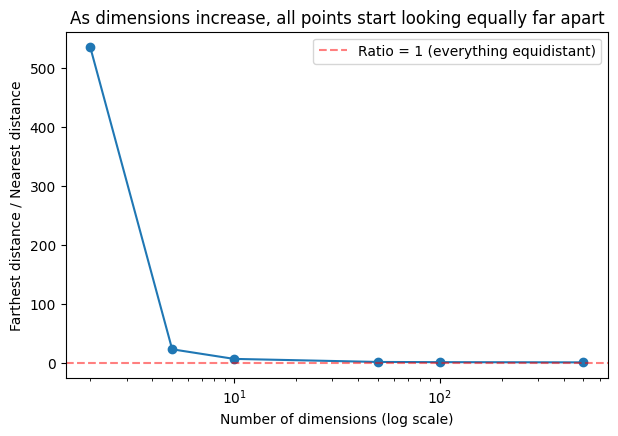

   2 dimensions -- farthest/nearest ratio: 534.86
   5 dimensions -- farthest/nearest ratio: 23.41
  10 dimensions -- farthest/nearest ratio: 7.15
  50 dimensions -- farthest/nearest ratio: 1.97
 100 dimensions -- farthest/nearest ratio: 1.62
 500 dimensions -- farthest/nearest ratio: 1.25


In [ ]:
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(0)
dimensions_to_test = [2, 5, 10, 50, 100, 500]
distance_ratios = []

for d in dimensions_to_test:
    points = rng.uniform(0, 1, size=(200, d))
    distances = pairwise_distances(points)
    np.fill_diagonal(distances, np.nan)   # ignore each point's distance to itself
    ratio = np.nanmax(distances) / np.nanmin(distances)
    distance_ratios.append(ratio)

plt.figure(figsize=(7, 4.5))
plt.plot(dimensions_to_test, distance_ratios, marker='o')
plt.xscale('log')
plt.xlabel('Number of dimensions (log scale)')
plt.ylabel('Farthest distance / Nearest distance')
plt.title('As dimensions increase, all points start looking equally far apart')
plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Ratio = 1 (everything equidistant)')
plt.legend()
plt.show()

for d, r in zip(dimensions_to_test, distance_ratios):
    print(f"{d:4d} dimensions -- farthest/nearest ratio: {r:.2f}")


At 2 dimensions, the farthest pair of points is hundreds of times farther apart than the nearest pair — distance is meaningful, "nearest neighbor" is a well-defined idea. By 500 dimensions, that ratio has collapsed to barely above 1 — every pair of points is nearly the same distance from every other pair. This is precisely why techniques like PCA, Kernel PCA, and UMAP (Section 6) matter so much for real datasets: **they're not just for making pretty visualizations — they're often necessary to make distance-based methods work at all** once you have more than a handful of features. It's also directly relevant to next week's material: embedding-based semantic search relies entirely on distances between high-dimensional vectors being meaningful, which is exactly the property that starts to break down as dimensionality grows unchecked.

The standard distance formula is **Euclidean distance** — the straight-line distance between two points, generalized from the Pythagorean theorem to however many dimensions you have.

**In 2D**, between two points $(x_1, y_1)$ and $(x_2, y_2)$:

$$d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$$

**In general, for $n$ dimensions**, between two rows $\mathbf{p} = (p_1, p_2, \ldots, p_n)$ and $\mathbf{q} = (q_1, q_2, \ldots, q_n)$:

$$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

In words: for each feature, subtract one row's value from the other's, square it, sum all those squared differences across every feature, then take the square root. It's exactly the same formula regardless of whether $n$ is 2 (a scatter plot) or 17 (our job postings features) or 500 (the curse-of-dimensionality demo) — this is a good concrete example of the "direction is just instructions, not a picture" idea: the formula doesn't care how many dimensions it's summing over.

**This is exactly what powered the curse-of-dimensionality demo** — `sklearn.metrics.pairwise_distances` was computing precisely this formula between every pair of points, at each dimension count, which is how we got that farthest/nearest ratio collapsing toward 1.

A couple of related things worth knowing, since they come up constantly alongside this formula:

- **Squared Euclidean distance** — the same formula without the final square root — is often used instead in practice, since it's cheaper to compute and preserves the same ordering (if A is closer than B, that stays true whether or not you take the square root).
- **Standardization matters here too** — just like with PCA and covariance, if your features are on wildly different scales (say, salary in dollars vs. remote_ratio as 0/50/100), the distance formula will be dominated by whichever feature has the largest raw numbers, regardless of which feature is actually more informative. That's why we standardized before computing distances, covariance, or PCA throughout this whole thread — same underlying reason each time.
- **Other distance metrics exist** (Manhattan/city-block distance, cosine distance — which we'll use for embeddings/semantic search, since it measures angle rather than straight-line distance) — Euclidean is just the most common default, not the only option.


## 3. Regularization: Keeping Models Honest as Dimensions Grow

Our job postings dataset has 15 individual skill columns, plus several categorical columns that, once encoded, expand into many more. With that many features and only 2,000 rows, a model has a lot of room to find spurious patterns — a skill or two that happens to correlate with salary in this particular sample purely by chance, not because of any real relationship.

**Regularization** is a family of techniques that discourage a model from leaning too heavily on any single feature, by penalizing large coefficients during training. Two common versions:

* **Ridge (L2) regularization** — shrinks all coefficients toward zero, more aggressively for features that don't help much, but rarely all the way to exactly zero.
* **Lasso (L1) regularization** — can shrink coefficients all the way to exactly zero, effectively removing features from the model entirely. This makes Lasso useful when you suspect many of your features are irrelevant.

Let's fit a plain linear regression alongside Ridge and Lasso on our numeric + skill features, and see how the coefficients differ.


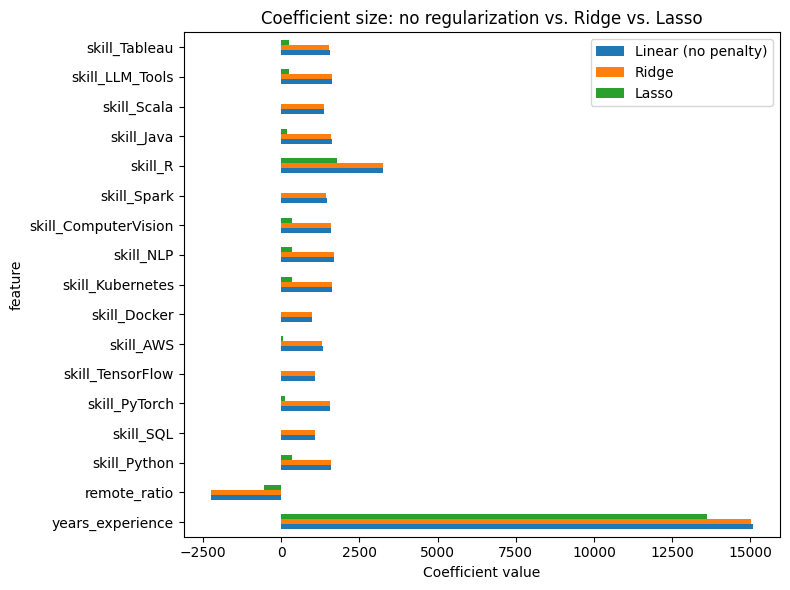

Features Lasso zeroed out entirely: 5 of 17


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

numeric_features = ["years_experience", "remote_ratio"] + list(skill_df.columns)
X = jobs[numeric_features].values
y = jobs["salary"].values

# Standardize features first -- regularization penalizes coefficient SIZE,
# so features need to be on comparable scales for that penalty to be fair.
X_scaled = StandardScaler().fit_transform(X)

linear_model = LinearRegression().fit(X_scaled, y)
ridge_model = Ridge(alpha=10.0).fit(X_scaled, y)
lasso_model = Lasso(alpha=1400.0).fit(X_scaled, y)

coef_comparison = pd.DataFrame({
    "feature": numeric_features,
    "Linear (no penalty)": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
}).set_index("feature")

coef_comparison.plot(kind="barh", figsize=(8, 6))
plt.title("Coefficient size: no regularization vs. Ridge vs. Lasso")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

print(f"Features Lasso zeroed out entirely: {(lasso_model.coef_ == 0).sum()} of {len(numeric_features)}")


Notice two things: Ridge's bars are generally a bit smaller than plain linear regression's across the board (shrinkage, not elimination), while Lasso has likely zeroed out several features completely — a form of automatic feature selection. Given that `years_experience` and `skill_count`-driving skills genuinely determine salary in how we built this dataset, both regularized models should still keep those large, while shrinking or eliminating the skills that don't actually matter (recall we only made skill *count* matter, not any individual skill) — a nice, concrete illustration of regularization doing its job correctly.


## 4. SVD: Finding the Simple Structure Hiding in a Matrix

**Singular Value Decomposition (SVD)** is a way of breaking any matrix down into three simpler pieces that, multiplied back together, reconstruct the original matrix exactly. The useful part for us isn't the exact reconstruction — it's that SVD ranks the "directions" of the data by how much of the matrix's structure they explain, which means you can often keep only the most important few and get a very good *approximation* using dramatically less information. This "keep only what matters most" idea is the same instinct behind PCA in the next section — in fact, PCA is built directly on top of SVD.

**Note on Direction:** A direction is just a set of instructions, not a picture. In 3D, direction happens to look like an arrow, but really it's just three numbers: "move this much along x, this much along y, this much along z." Nothing about that idea requires stopping at 3(D) — it's just as valid to say "move this much along years_experience, this much along skill_count, this much along remote_ratio, ..." for 17 numbers instead of 3. You lose the picture, but the instructions still make complete sense.

A classic, visual way to feel this is image compression. Let's build a synthetic image with real structure in it (not random noise), and see how well SVD can approximate it using only a handful of its components.


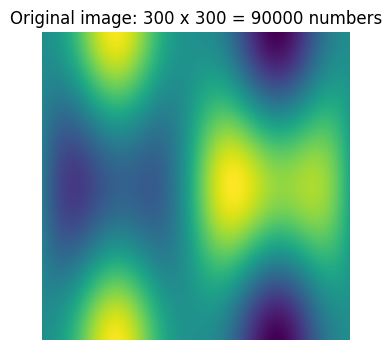

In [ ]:
# Build a synthetic image with real underlying structure (a few overlapping
# gradients and a checkerboard pattern) rather than pure random noise --
# structured data is exactly where SVD compression shines.
size = 300
x = np.linspace(-3, 3, size)
y = np.linspace(-3, 3, size)
X_grid, Y_grid = np.meshgrid(x, y)

image = (
    np.sin(X_grid) * np.cos(Y_grid)
    + 0.5 * np.exp(-(X_grid**2 + Y_grid**2) / 3)
    + 0.3 * np.sin(3 * X_grid)
)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='viridis')
plt.title(f'Original image: {image.shape[0]} x {image.shape[1]} = {image.size} numbers')
plt.axis('off')
plt.show()


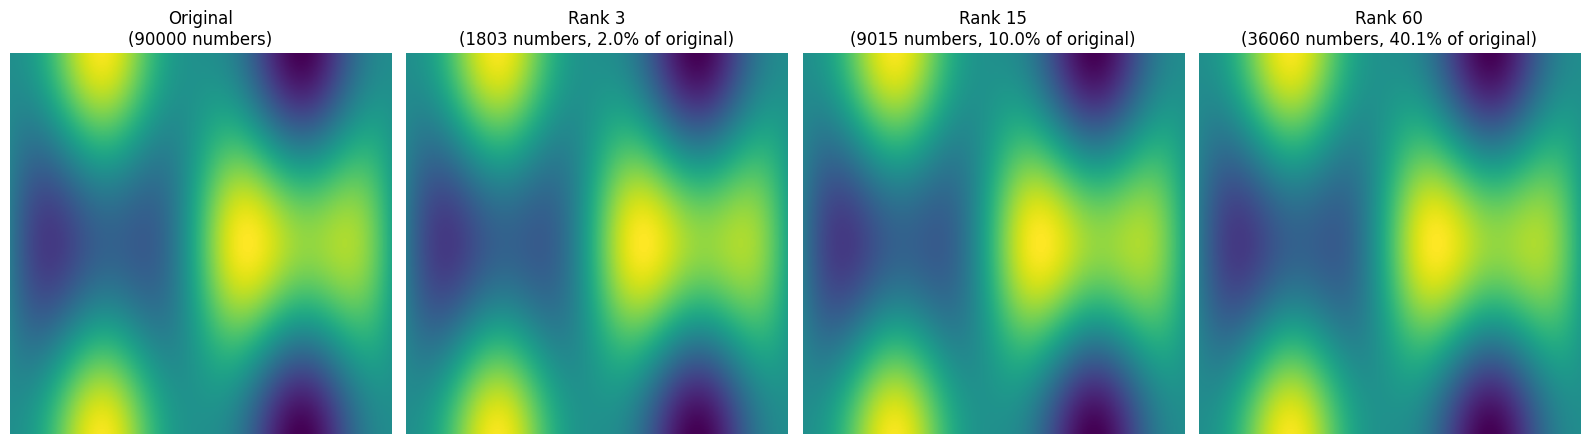

In [ ]:
# Decompose the image with SVD, then reconstruct it using only the
# top-k singular values/vectors, for a few different values of k.
U, singular_values, Vt = np.linalg.svd(image, full_matrices=False)

ranks_to_try = [3, 15, 60]
fig, axes = plt.subplots(1, len(ranks_to_try) + 1, figsize=(16, 4.5))

axes[0].imshow(image, cmap='viridis')
axes[0].set_title(f'Original\n({image.size} numbers)')
axes[0].axis('off')

for ax, k in zip(axes[1:], ranks_to_try):
    reconstruction = U[:, :k] @ np.diag(singular_values[:k]) @ Vt[:k, :]
    numbers_stored = k * (U.shape[0] + Vt.shape[1] + 1)   # U columns + Vt rows + singular values
    compression = numbers_stored / image.size
    ax.imshow(reconstruction, cmap='viridis')
    ax.set_title(f'Rank {k}\n({numbers_stored} numbers, {compression:.1%} of original)')
    ax.axis('off')

plt.tight_layout()
plt.show()


Notice how the reconstruction with 2% of the original information is visually indistinguishable from the original. This works because our synthetic image has real, repeating structure — SVD is very good at exploiting structure, and much less impressive on pure random noise (which has no structure to compress). Real-world data — including the numeric parts of a dataset like our job postings table — very often has exactly this kind of exploitable structure, which is precisely what the next section's dimensionality reduction methods take advantage of.


## 5. PCA, Kernel PCA, and UMAP: Three Ways to Shrink High-Dimensional Data

Section 3 showed why high-dimensional data is a problem; Section 5 showed the basic idea (SVD) that makes shrinking it possible. Now let's compare three actual tools for doing that shrinking, applied to our job postings dataset's numeric and skill features (17 dimensions), reduced down to 2 dimensions we can actually plot and look at.

* **PCA (Principal Component Analysis)** — built directly on SVD. Finds the directions of greatest *linear* variation in the data and projects onto those. Fast, well-understood, and a very reasonable default — but it can only capture straight-line relationships, not curved or looped structure.
* **Kernel PCA** — the same basic idea as PCA, but first maps the data through a nonlinear function before finding directions of variation, letting it capture some curved/nonlinear structure that plain PCA would miss.
* **UMAP (Uniform Manifold Approximation and Projection)** — a more recent, more flexible nonlinear technique, particularly good at preserving *local neighborhood* structure (which points are close to which), often producing visually clearer, more separated clusters than PCA — at the cost of being more of a "black box," with results that can shift noticeably depending on its settings.

Let's run all three on the same data and compare.


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


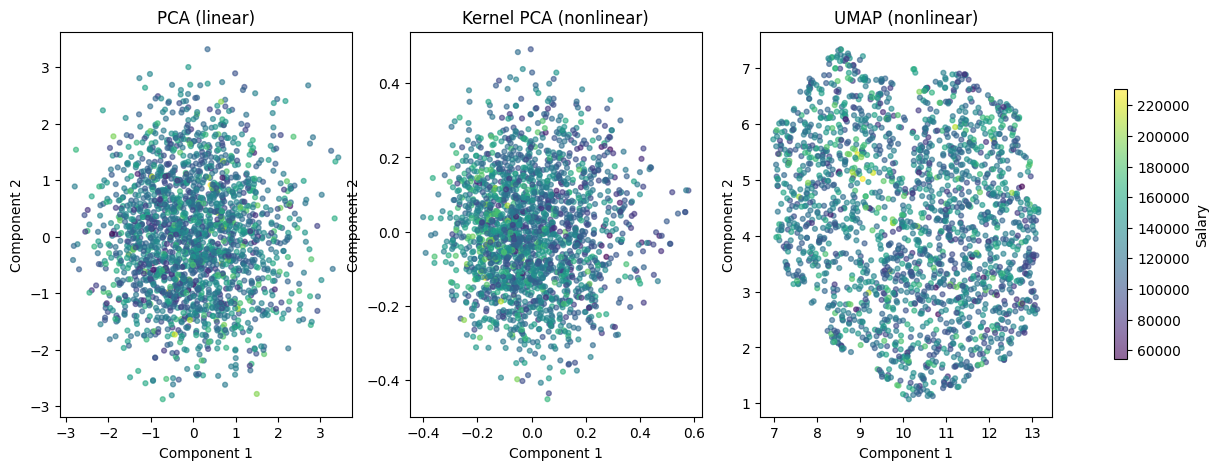

In [ ]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
import umap

reduction_features = ["years_experience", "remote_ratio"] + list(skill_df.columns)
X_reduce = StandardScaler().fit_transform(jobs[reduction_features].values)

pca_result = PCA(n_components=2).fit_transform(X_reduce)
kpca_result = KernelPCA(n_components=2, kernel="rbf", gamma=0.05).fit_transform(X_reduce)
umap_result = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduce)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
color_by = jobs["salary"]

for ax, result, title in zip(
    axes,
    [pca_result, kpca_result, umap_result],
    ["PCA (linear)", "Kernel PCA (nonlinear)", "UMAP (nonlinear)"],
):
    scatter = ax.scatter(result[:, 0], result[:, 1], c=color_by, cmap="viridis", alpha=0.6, s=12)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig.colorbar(scatter, ax=axes, label="Salary", shrink=0.7)
plt.show()


The most useful point in this particular output is the color — look at all three panels and notice salary (the color) doesn't organize cleanly by region in any of them. High-salary (yellow) and low-salary (dark purple) points are scattered fairly evenly throughout each shape, rather than clustering into distinct colored regions. That's a legitimate and useful finding: it tells us that these 17 features, compressed to 2D, don't cleanly separate people by salary — which lines up with what we already know from the regularization section (most individual skills don't matter; only the aggregate skill count and experience do, and PCA/UMAP can't "know" to prioritize those over the 15 other largely-noise skill columns).

All three methods are compressing the same 17-dimensional data down to 2 dimensions, colored by salary so you can see whether the reduction preserved anything meaningful about our target variable. Notice how differently they can look: PCA tends to produce a smoother, more continuous spread since it's confined to straight-line projections; UMAP often produces more visually distinct clumps, since it's explicitly optimizing to preserve which points are each other's neighbors, not overall variance.

**A caution worth keeping in mind:** UMAP's visual separation can be sensitive to its settings and doesn't always correspond to genuinely distinct underlying groups. Treat all three as different *lenses* on the same data, not as a competition with an objective winner. Which one is "best" depends entirely on what you're using it for — a quick sanity-check visualization (PCA is fine and fast), or a serious search for cluster structure (Kernel PCA or UMAP may reveal more, but need more careful interpretation).


## 6. Modern Tabular Models: CatBoost, LightGBM, and TabPFN

This section is our centerpiece for this talk: comparing three real, current approaches to predicting a number (salary) from a messy tabular dataset — two well-established gradient boosting libraries, and one of the newer tabular foundation models challenging them.




### 6.1 The problem gradient boosting libraries usually make you solve first: categorical encoding

Our dataset has two high-cardinality categorical columns: `job_title` (30 categories) and `city` (24 categories). Most machine learning models — including, by default, libraries like scikit-learn's own gradient boosting — can't work with text categories directly. The standard fix is **one-hot encoding**: turning each category into its own 0/1 column. Let's see what that actually does to our dataset.

In [ ]:
categorical_columns = ["education", "job_title", "city", "company_size"]
one_hot_encoded = pd.get_dummies(jobs, columns=categorical_columns, drop_first=True)

print(f"Original dataset:      {jobs.shape[1]} columns")
print(f"One-hot encoded:       {one_hot_encoded.shape[1]} columns")
print(f"Columns added just for job_title and city: "
      f"{jobs['job_title'].nunique() + jobs['city'].nunique() - 2}")


Original dataset:      23 columns
One-hot encoded:       75 columns
Columns added just for job_title and city: 52


That's the pain point worth sitting with for a second: two categorical columns turned into dozens of new columns, most of which are mostly zeros. This is exactly the workflow that tends to produce blank stares when described abstractly — it's much more convincing to see the column count explode in front of you. And this is a *mild* case; real HR, e-commerce, or logistics data often has categorical columns with hundreds or thousands of distinct values, where one-hot encoding becomes genuinely unwieldy — huge, sparse, memory-hungry matrices.

### 6.2 CatBoost: skip the encoding step entirely

**CatBoost** (from "Categorical Boosting") is a gradient boosting library built from the ground up to handle categorical columns natively — you hand it the raw dataframe, tell it which columns are categorical, and it figures out how to use them internally, without you one-hot encoding anything first.


In [ ]:
!pip install catboost -q

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

feature_columns = ["years_experience", "education", "job_title", "city",
                    "company_size", "remote_ratio"] + list(skill_df.columns)
X_raw = jobs[feature_columns]
y = jobs["salary"]

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Point CatBoost directly at the ORIGINAL categorical columns -- no encoding step at all.
categorical_feature_names = ["education", "job_title", "city", "company_size"]

catboost_model = CatBoostRegressor(
    iterations=300, learning_rate=0.1, depth=6, verbose=False, random_state=42
)
catboost_model.fit(X_train, y_train, cat_features=categorical_feature_names)

catboost_predictions = catboost_model.predict(X_test)
catboost_mae = mean_absolute_error(y_test, catboost_predictions)
print(f"CatBoost -- trained on raw categorical columns, no encoding step.")
print(f"CatBoost Mean Absolute Error: ${catboost_mae:,.0f}")


CatBoost -- trained on raw categorical columns, no encoding step.
CatBoost Mean Absolute Error: $8,395


That's the whole pattern: raw dataframe in, a list of which columns are categorical, and CatBoost handles the rest internally — no `pd.get_dummies`, no exploded column count, no sparse matrix. This is CatBoost's actual selling point, and it's a narrow, concrete one worth remembering: **reach for CatBoost specifically when your data has meaningful categorical columns, especially high-cardinality ones, that you don't want to hand-encode.**

### 6.3 LightGBM: the lean, fast alternative

**LightGBM** is another gradient boosting library, well known for being fast and memory-efficient, especially on large datasets. It has *some* categorical support, but it's less central to its design than CatBoost's — LightGBM's real strength is raw training speed. Let's fit it on the same data using its native categorical handling, and compare.


In [ ]:
import lightgbm as lgb

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
for col in categorical_feature_names:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

lightgbm_model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, verbosity=-1
)
lightgbm_model.fit(X_train_lgb, y_train, categorical_feature=categorical_feature_names)

lightgbm_predictions = lightgbm_model.predict(X_test_lgb)
lightgbm_mae = mean_absolute_error(y_test, lightgbm_predictions)
print(f"LightGBM Mean Absolute Error: ${lightgbm_mae:,.0f}")
print(f"CatBoost Mean Absolute Error: ${catboost_mae:,.0f}")


LightGBM Mean Absolute Error: $8,692
CatBoost Mean Absolute Error: $8,395


The two should land in a similar range on a dataset this size — the real difference between them shows up less in raw accuracy on a tidy benchmark like this, and more in **development experience and speed**: CatBoost tends to need less preprocessing and hyperparameter tuning to get solid results out of the box, especially with rich categorical data, while LightGBM tends to train faster and scale further on very large datasets. Neither is unconditionally "better" — they're suited to different situations, which is exactly what your Tool Evaluation Card should capture.

### 6.4 TabPFN: a fundamentally different approach

Everything above works by *training* — the model adjusts its internal parameters to fit your specific data. **TabPFN** (Tabular Prior-data Fitted Network) represents a different paradigm: a **tabular foundation model**, pretrained once on millions of synthetic datasets, that makes predictions on *your* data via **in-context learning** — it reads your training rows as context and predicts directly, without any gradient-based training on your data at all. The appeal is real: near-zero setup, often strong accuracy without any hyperparameter tuning, especially on small-to-medium datasets.

It comes with real constraints worth knowing before you reach for it: current versions cap out in the tens of thousands of rows and a few thousand features (it's not built for very large tables), the model weights are free but licensed for **non-commercial use only**, and it needs to download a pretrained model on first use — none of which is true of CatBoost or LightGBM. The code pattern, however, is deliberately simple — a familiar scikit-learn-style `fit`/`predict` interface:

```python
# Note: this cell needs internet access to download pretrained weights the first
# time it runs, and only works within TabPFN's supported row/feature limits.
from tabpfn import TabPFNRegressor

tabpfn_model = TabPFNRegressor()
tabpfn_model.fit(X_train_numeric, y_train)          # "fit" here mostly just stores context
tabpfn_predictions = tabpfn_model.predict(X_test_numeric)
```

(Note: TabPFN's current public release expects numeric-encoded input rather than CatBoost's raw-categorical style, so you'd still encode `job_title` and `city` first if you wanted to use it on this dataset — one of several practical trade-offs worth weighing.)

### 6.5 Reading the benchmark claims critically

Here's the part that matters most for your career, not just this dataset: **as of 2026, tabular foundation models like TabPFN are genuinely competitive with, and on some published benchmarks beat, tuned gradient boosting models — but the claim deserves scrutiny, not blind acceptance.** A few things worth knowing before you'd cite a "TFMs beat GBDTs" headline in a work setting:

* Published rankings can be **protocol-sensitive** — some benchmark wins for foundation models depend on ensembling multiple runs together; compared one-tuned-model-to-one-tuned-model, gradient boosting sometimes regains the lead.
* Some of the most-cited benchmark numbers for TabPFN come from **the same lab that built TabPFN** — not necessarily wrong, but a real conflict-of-interest flag that an independent benchmark would resolve more convincingly.
* Foundation models currently have **hard scale limits** that tuned gradient boosting simply doesn't — for a dataset with millions of rows, this entire debate is moot, and CatBoost/LightGBM remain the practical choice regardless of what a small-dataset leaderboard says.

None of this means "don't trust TabPFN" — it means **read benchmark claims the way you'd read any other empirical claim: check who ran it, under what conditions, and whether it applies to your actual situation.** That's the transferable skill this section is really teaching, underneath the specific tool names.


### Running TabPFN

TabPFN needs fully numeric input, not the raw categorical columns CatBoost was happy to use directly. The cell below reuses the same one-hot encoding from Section 7.1, and the same train/test split settings as the CatBoost and LightGBM sections, so all three models are compared fairly on identical data.

TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"

In [ ]:
pip install tabpfn -q

In [ ]:
# TabPFN needs fully numeric input -- reuse the one-hot encoded version from Section 7.1
import os
from google.colab import userdata
os.environ["TABPFN_TOKEN"] = userdata.get('TABPFN_TOKEN')

from tabpfn import TabPFNRegressor   # reads the token at import time

numeric_features_for_tabpfn = pd.get_dummies(
    jobs[feature_columns], columns=categorical_feature_names, drop_first=True
)

X_train_numeric, X_test_numeric, y_train, y_test = train_test_split(
    numeric_features_for_tabpfn, y, test_size=0.2, random_state=42
)

tabpfn_model = TabPFNRegressor()
tabpfn_model.fit(X_train_numeric, y_train)
tabpfn_predictions = tabpfn_model.predict(X_test_numeric)

tabpfn_mae = mean_absolute_error(y_test, tabpfn_predictions)
print(f"TabPFN Mean Absolute Error: ${tabpfn_mae:,.0f}")
print(f"CatBoost Mean Absolute Error: ${catboost_mae:,.0f}")
print(f"LightGBM Mean Absolute Error: ${lightgbm_mae:,.0f}")

tabpfn-v3-regressor-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  233MB            

tabpfn-v3-regressor-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/tabpfn/validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


TabPFN Mean Absolute Error: $7,935
CatBoost Mean Absolute Error: $8,395
LightGBM Mean Absolute Error: $8,692


**The gap is modest, not dramatic** — TabPFN beats CatBoost by about \$460 (roughly 5.5%) and LightGBM by about \$757 (roughly 8.7%). That's a real edge, but it's the kind of margin worth treating with appropriate humility rather than declaring a decisive winner — especially on one train/test split of one synthetic dataset.

**This is exactly the "zero-tuning" comparison that makes TabPFN's pitch compelling.** CatBoost and LightGBM here were run with reasonable-but-fixed hyperparameters (`iterations=300`, `learning_rate=0.1`, `depth=6`); TabPFN needed none of that — no learning rate, no depth, no iteration count, nothing to tune. If you tuned CatBoost properly (a grid search or Optuna run), it's entirely plausible it would close this gap or overtake TabPFN — which is precisely the "protocol-sensitive" caveat from the TabArena discussion: default-vs-default is a different comparison than tuned-vs-tuned.

**Notice the trade-off, not just the number:** TabPFN got the best score here, but at real cost — an account, a license acceptance, an API token, and a slower first call to download weights, versus CatBoost's near-instant `pip install` and immediate `.fit()`. *was that extra setup friction worth $460?* For a production system processing millions of predictions where every fraction of a percent of accuracy has real dollar value (Affirm's credit risk use case, for instance) — quite possibly yes. That's the actual judgment call the "read benchmarks critically" thread has been building toward all week.

## 7. A Reusable Pattern: Structured Prompting for AI-Assisted Coding

If concepts matter more than syntax in this course, you need a reliable way to turn a concept you understand into working code without needing to memorize every library's API. The quality of what an AI assistant hands back depends heavily on how specifically you ask — a vague prompt gets a generic, often-wrong answer; a structured one gets something close to what you actually need.

Here's a simple, reusable template — written in a docstring style, the same shape as a Python function's documentation:

```
TASK:            What problem are you solving, in one sentence?
DATA SHAPE:      What does your data look like? Rows, columns, types
                 (flag anything unusual: categorical columns, missing
                 values, high cardinality, etc.)
LIBRARIES:       What should the code use? (be specific — library names
                 and, if you know it, version constraints)
CONSTRAINTS:     Any requirements? (must run in Colab, must not use
                 deprecated functions, needs to handle NaNs, etc.)
CHECK FOR:       What should you personally verify once you get code back?
```

Let's see it in action. Suppose you wanted code that compresses an image using SVD — a vague prompt like *"write me SVD code for images"* will likely get you something generic that may not even match your actual data. Here's the same request, structured:

```
TASK:            Compress a grayscale image using truncated SVD, and show
                 how image quality changes as I keep more or fewer
                 singular values.
DATA SHAPE:      A 2D numpy array representing a grayscale image
                 (values 0-255, shape roughly 400x400).
LIBRARIES:       numpy and matplotlib only.
CONSTRAINTS:     Show the reconstruction at 3 different ranks (e.g. 5, 20,
                 100) side by side, and report how much smaller each
                 reconstruction is in terms of stored numbers vs. the
                 original image.
CHECK FOR:       Does the code use full SVD or truncated/randomized SVD?
                 Full SVD on a large image is much slower than it needs
                 to be for this task — check whether the response
                 accounts for that.
```

That last "CHECK FOR" field is the most important one, and it's worth dwelling on: **you're not just asking for code, you're pre-committing to reviewing it critically.** This is the exact skill employers are asking for right now — not "can you prompt an AI," but "can you evaluate what it gives you and catch what's wrong or suboptimal."


### A Companion Habit: The Tool Evaluation Card

Alongside the prompting template, here's a second reusable format — this one for *you*, not for an AI assistant. Every time this course introduces a new tool (today: CatBoost and TabPFN; next week: embedding and retrieval tools), fill out a short card like this one:

```
TOOL:            [name]
TASK:            What kind of problem is this tool built for?
WHY THIS TOOL:   What does it do that the alternatives don't?
MINIMAL PATTERN: The smallest working code example that uses it
WATCH OUT FOR:   Gotchas, limits, or situations where you'd pick
                 something else instead
```

Notice this card has almost the same shape as the prompting template above — that's intentional. A well-filled-out Tool Evaluation Card *is* most of a good structured prompt already. Fill these out as we go through Sections 5 and 6 below; you'll reuse the exact same format next week.


### Fill out your Tool Evaluation Cards

Fill out a card for TabPFN based on what we just covered. Here's CatBoost's, filled out as an example:

```
TOOL:            CatBoost
TASK:            Predicting a target (salary) from tabular data with
                 meaningful categorical columns.
WHY THIS TOOL:   Handles categorical features natively -- no one-hot
                 encoding, no exploded column count, minimal preprocessing.
MINIMAL PATTERN: CatBoostRegressor().fit(X, y, cat_features=[...])
WATCH OUT FOR:   Training can be slower than LightGBM on very large
                 datasets; still needs a train/test split and normal
                 overfitting checks like any other boosted model.
```

Now try TabPFN yourself — you have everything.


### Try a Structured Prompt

Based on the following example, I would like you to *generate code to visualize how PCA, Kernel PCA, and UMAP each handle a dataset with two curved, overlapping clusters — plot all three side by side. Be sure to include all the necessary libraries.*


```
TASK:            Compress a grayscale image using truncated SVD, and show
                 how image quality changes as I keep more or fewer
                 singular values.
DATA SHAPE:      A 2D numpy array representing a grayscale image
                 (values 0-255, shape roughly 400x400).
LIBRARIES:       numpy and matplotlib only.
CONSTRAINTS:     Show the reconstruction at 3 different ranks (e.g. 5, 20,
                 100) side by side, and report how much smaller each
                 reconstruction is in terms of stored numbers vs. the
                 original image.
CHECK FOR:       Does the code use full SVD or truncated/randomized SVD?
                 Full SVD on a large image is much slower than it needs
                 to be for this task — check whether the response
                 accounts for that.
```

## 8. Closing: What to Carry Forward

Three reusable things came out of this notebook, and all three are meant to travel with you past this one week:

1. **The structured prompting template** — task, data shape, libraries, constraints, and (critically) what to check — for getting useful code out of an AI assistant instead of a generic guess.
2. **The Tool Evaluation Card** — a consistent format for capturing what a new tool is for, why you'd reach for it, its minimal working pattern, and its limits. You'll use this same format next week for embedding and retrieval tools (Sentence-Transformers, HNSW, hybrid BM25 search), and again throughout the rest of the semester.
3. **A habit of reading benchmark claims critically** — checking who ran a comparison, under what conditions, before treating "X beats Y" as settled fact. This applies just as much to the vector search and knowledge graph tools coming up as it does to CatBoost vs. TabPFN.

On the content side: high-dimensional data breaks the assumptions distance-based methods rely on (Section 3); regularization and dimensionality reduction (Sections 4-6) are two different responses to that same underlying problem — one constrains the model, the other reshapes the data; and Section 7's tabular model comparison is a live, current example of exactly the kind of "which tool, and why" judgment call you'll be making constantly in real AI-engineering work, where the "best" tool changes benchmark-to-benchmark and the honest answer is almost always "it depends on your constraints."


## Supplemental Supporting Notebooks

The following notebooks can be found in DSChunks.

1. **`Knowledge Discovery Frameworks.ipynb`** — KDD, CRISP-DM, SEMMA, and TDSP (Microsoft's methodology), with a side-by-side pipeline diagram and comparison table. Companion to opening framing (and really the whole semester's).

2. **`Singular Value Decomposition.ipynb`** — matrix decomposition, low-rank approximation, and the image-compression demo. Companion to SVD section directly.

3. **`Kernel PCA vs UMAP.ipynb`** — linear vs. nonlinear dimensionality reduction, using the two-crescents dataset to make the contrast visually obvious. Companion to PCA/Kernel PCA/UMAP section.

4. **`CatBoost.ipynb`** — the one-hot-explosion pain point followed by CatBoost's native categorical handling. Companion to tabular models section, isolated as a standalone reference independent of the job-postings dataset.

5. **`Eigenvectors and Eigenvalues by Hand.ipynb`** — the full by-hand derivation (covariance matrix → $\det(\Sigma-\lambda I)=0$ → eigenvector → PC1 scores → verification), grew out of our conversation about how PCA actually works. Companion to PCA section, one level deeper than the module notebook goes.

6. **`Covariance, Regression Coefficients and Multicollinearity.ipynb`** — same covariance-matrix mechanics, applied to regression instead of PCA, closing with a leave-one-out demo of multicollinearity. This one is a bit more of a bridge — it connects high-dimensional geometry content back to regression, showing that the underlying math (reading off-diagonal covariances) is the same skill.

7. **`Boosting.ipynb`** - Boosting is an ensemble meta-algorithm that combines multiple weak learners sequentially to create a single, highly accurate strong learner.

8. **`Regularization.ipynb`** - In mathematics, statistics, finance, computer science, particularly in machine learning and inverse problems, regularization is the process of solving ill-posed problems or to prevent overfitting. Regularization can be applied to objective functions in ill-posed optimization problems. The regularization term, or penalty, imposes a cost on the optimization function to make the optimal solution unique.
